# 模型训练

本 Notebook 用于模型训练和调优。

In [ ]:
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

# 加载环境变量
env_path = Path('../.env').resolve()
if not env_path.exists():
    env_path = Path('.env').resolve()
if env_path.exists():
    PROJECT_ROOT = env_path.parent
else:
    PROJECT_ROOT = Path.cwd()
if env_path.exists():
    load_dotenv(env_path, encoding='gb18030')

DATA_DIR = PROJECT_ROOT / 'data'
RAW_DATA_DIR = DATA_DIR / 'raw'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
HF_CACHE_DIR = PROJECT_ROOT / 'hf_cache'

for d in [DATA_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR, MODEL_DIR, OUTPUT_DIR, HF_CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)
# 设置 HuggingFace 缓存
os.environ['HF_HOME'] = str(HF_CACHE_DIR)
os.environ['TRANSFORMERS_CACHE'] = str(HF_CACHE_DIR / 'transformers')

# 创建必要的目录
print(f" 项目根目录: {PROJECT_ROOT}")
print(f" 数据目录: {DATA_DIR}")
print(f" 模型目录: {MODEL_DIR}")
print(f" 输出目录: {OUTPUT_DIR}")
print(f" HF 缓存目录: {os.environ['HF_HOME']}")

# 把 src 加入 Python 路径
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

In [1]:
# 导入必要的库
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import load_dataset

print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA版本: {torch.version.cuda}")
    print(f"GPU数量: {torch.cuda.device_count()}")
    print(f"当前GPU: {torch.cuda.get_device_name(0)}")

PyTorch版本: 2.8.0+cu128
CUDA可用: True
CUDA版本: 12.8
GPU数量: 1
当前GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 数据准备

加载和预处理训练数据。

In [ ]:
# 加载数据集
# dataset = load_dataset('csv', data_files=str(PROCESSED_DATA_DIR / 'train_data.csv'))
# print(dataset)

## 模型训练

配置并训练模型。

任务4

In [7]:
import json
import os
from pathlib import Path

processed_dir = Path("D:/Jupyter profile/汽车信息安全风险评估/data/processed")
output_dir = Path("D:/Jupyter profile/汽车信息安全风险评估/data/final/head5")

subfolders = [
    "11-ASE-TARA1.4",
    "15-ASE-TARA1.4",
    "MY26",
    "P20_TARA_v1.2-20260121",
    "T9TARA -V1.2",
    "少林客车TARA-1.3",
    "庆铃-轻卡4KB1_TARA_v1.0--最终版",
    "智己S32L-TARA",
    "欧胜传统车TARA-V1.5"
]

train_data = []
val_data = []
total_count = 0

for subfolder in subfolders:
    json_dir = processed_dir / subfolder
    if not json_dir.exists():
        print(f"Warning: {subfolder} not found")
        continue
    
    json_files = list(json_dir.glob("*.json"))
    for json_file in json_files:
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            if isinstance(data, list):
                for item in data:
                    if all(k in item for k in ["攻击路径", "暴露时间", "专业经验", "所需信息", "机会窗口", "所需设备"]):
                        input_text = item["攻击路径"]
                        output_text = json.dumps({
                            "暴露时间": item["暴露时间"],
                            "专业经验": item["专业经验"],
                            "所需信息": item["所需信息"],
                            "机会窗口": item["机会窗口"],
                            "所需设备": item["所需设备"]
                        }, ensure_ascii=False)
                        
                        record = {
                            "input": input_text,
                            "output": output_text
                        }
                        
                        if total_count % 10 == 9:
                            val_data.append(record)
                        else:
                            train_data.append(record)
                        total_count += 1
        except Exception as e:
            print(f"Error processing {json_file}: {e}")

print(f"Total records: {len(train_data) + len(val_data)}")
print(f"Train records: {len(train_data)}")
print(f"Val records: {len(val_data)}")

with open(output_dir / "train.json", 'w', encoding='utf-8') as f:
    json.dump(train_data, f, ensure_ascii=False, indent=2)

with open(output_dir / "val.json", 'w', encoding='utf-8') as f:
    json.dump(val_data, f, ensure_ascii=False, indent=2)

print(f"Data exported to {output_dir}")

Total records: 137277
Train records: 123550
Val records: 13727
Data exported to D:\Jupyter profile\汽车信息安全风险评估\data\final\head5


In [1]:
pip install networkx matplotlib

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


共生成 162 条有效攻击路径（多源 BFS 最短路径框架）：
1. [BLE信道] -> BLE
2. [BLE信道] -> 遥控钥匙
3. [Bluetooth] -> CDC
4. [Bluetooth] -> CDC -> [A2B] -> AMP
5. [Bluetooth] -> CDC -> [CANFD] -> AMP
6. [Bluetooth] -> CDC -> [CANFD] -> BDCR
7. [Bluetooth] -> CDC -> [CANFD] -> IC
8. [Bluetooth] -> CDC -> [CANFD] -> LBMS
9. [Bluetooth] -> CDC -> [CANFD] -> REA
10. [Bluetooth] -> CDC -> [FPDLINK] -> IC
11. [Bluetooth] -> CDC -> [FPDLINK] -> IVI
12. [Bluetooth] -> CDC -> [GMSL] -> DMS
13. [Bluetooth] -> CDC -> [GMSL] -> MDC
14. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [CANFD] -> FR
15. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [CANFD] -> USS ECU
16. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [ETH] -> Lidar
17. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [GMSL] -> FEC
18. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [GMSL] -> LRC-FC
19. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [GMSL] -> MRC-RC
20. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [GMSL] -> MRC-SC
21. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [GMSL] -> SRC-FC
22. [Bluetooth] -> CDC -> [GMSL

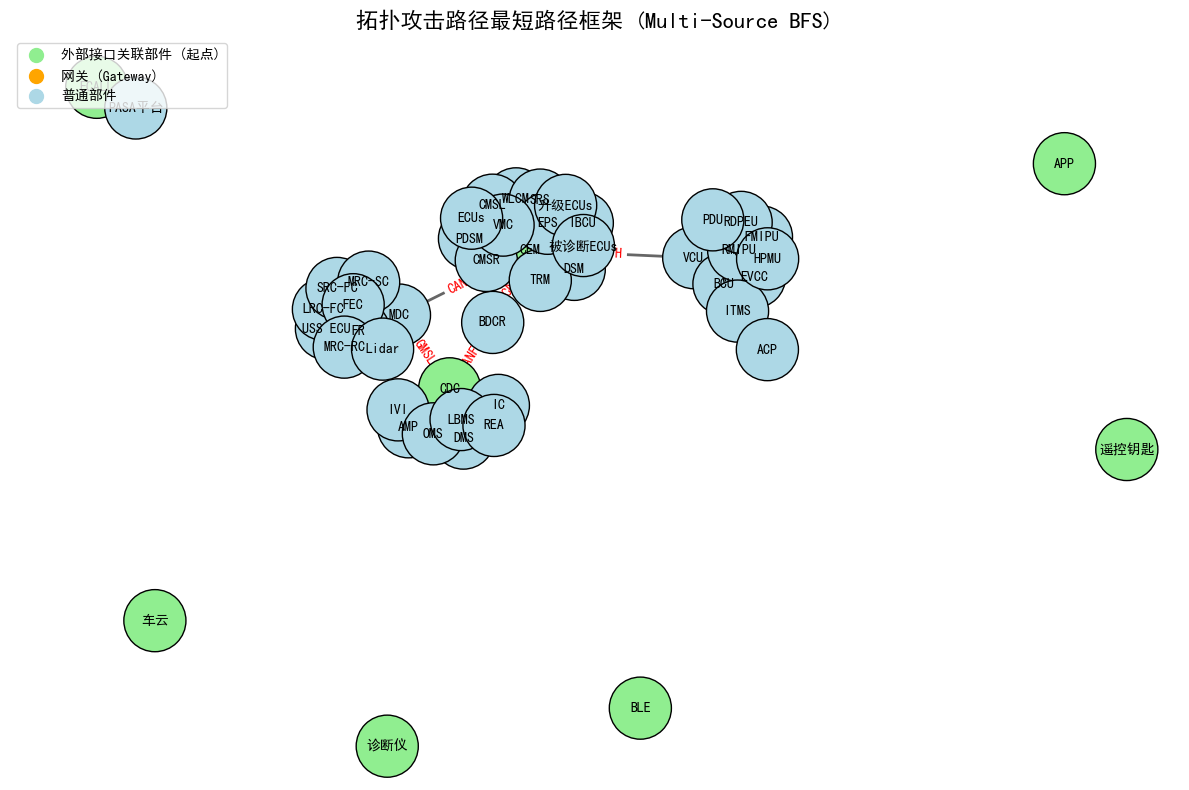

In [1]:
import json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, deque


# ==========================================
# 1. Data Models
# ==========================================
class TopologyElementType:
    COMPONENT = 1
    GATEWAY = 2
    EXTERNAL_COMPONENT = 3
    LINE = 4


class TopologyElement:
    def __init__(self, id, name="", type=None, color="",
                 source_id=None, target_id=None, is_gateway=False):
        self.id = id
        self.name = name
        self.type = type
        self.color = color
        self.source_id = source_id
        self.target_id = target_id
        self.is_gateway = is_gateway
        self.ids = []  # all IDs of same-name components (before dedup)


class PathNode:
    def __init__(self, component_name_id, component_name,
                 pre_component_name_id, pre_component_name,
                 line_id, color, is_gateway):
        self.component_name_id = component_name_id
        self.component_name = component_name
        self.pre_component_name_id = pre_component_name_id
        self.pre_component_name = pre_component_name
        self.line_id = line_id
        self.color = color
        self.is_gateway = is_gateway


# ==========================================
# 2. Topology Parsing
# ==========================================
class TopologyMapUtil:
    @staticmethod
    def list_element_vo(cells):
        components = []
        for cell in cells:
            ele = TopologyElement(id=cell.get("id"))
            shape = cell.get("shape", "")
            attrs = cell.get("attrs", {})

            if shape == "custom-rounded-rect":
                stroke = attrs.get("body", {}).get("stroke", "")
                ele.type = (TopologyElementType.GATEWAY if stroke == "#016AFF"
                            else TopologyElementType.COMPONENT)
                ele.is_gateway = (stroke == "#016AFF")
                ele.color = stroke
                ele.name = attrs.get("text", {}).get("text", "")

            elif shape == "custom-rounded-rect-dash":
                ele.type = TopologyElementType.EXTERNAL_COMPONENT
                ele.color = attrs.get("body", {}).get("stroke", "")
                ele.name = attrs.get("text", {}).get("text", "")

            elif shape == "edge":
                ele.type = TopologyElementType.LINE
                ele.color = attrs.get("line", {}).get("stroke", "")
                ele.source_id = cell.get("source", {}).get("cell")
                ele.target_id = cell.get("target", {}).get("cell")

            components.append(ele)
        return components

    @staticmethod
    def get_distinct_components(element_vos):
        components = [
            e for e in element_vos
            if e.type in (TopologyElementType.COMPONENT,
                          TopologyElementType.GATEWAY,
                          TopologyElementType.EXTERNAL_COMPONENT)
            and e.name
        ]
        com_name_map = defaultdict(list)
        for c in components:
            com_name_map[c.name].append(c)

        distinct = []
        for name, elements in com_name_map.items():
            first = elements[0]
            first.ids = [e.id for e in elements]
            distinct.append(first)
        return distinct


# ==========================================
# 3. Multi-Source BFS: Shortest Path Framework
# ==========================================
def compute_shortest_path_framework(external_interfaces, element_vos,
                                    protocol_legends, distinct_components):
    """
    Multi-source BFS (O(V+E)) computes the shortest distance from ANY
    external-interface component to EVERY topology node in a single pass,
    then reconstructs only the shortest paths via predecessor tracking.

    Compared to enumerating ALL paths (exponential) and filtering:
        Original BFS:    O(b^d)  — enumerates every possible walk
        Multi-source:    O(V+E)  — one BFS from all sources simultaneously

    Returns:
        source_target_paths: dict (source_id, target_id) → list[list[PathNode]]
        com_dic:             dict component_id → TopologyElement
    """
    # --- 1. Build ID mapping for duplicate component names ---
    many_to_one_id_map = {}
    for comp in distinct_components:
        for old_id in comp.ids:
            many_to_one_id_map[old_id] = comp.id

    valid_colors = [p['color'] for p in protocol_legends]

    # --- 2. Filter valid lines and remap their source/target ---
    lines = [e for e in element_vos
             if e.type == TopologyElementType.LINE and e.color in valid_colors]
    for line in lines:
        line.source_id = many_to_one_id_map.get(line.source_id, line.source_id)
        line.target_id = many_to_one_id_map.get(line.target_id, line.target_id)

    # --- 3. Build undirected adjacency (edge tagged with protocol color) ---
    com_dic = {c.id: c for c in distinct_components}
    adj = defaultdict(list)          # node_id → [(neighbor_id, color)]
    for line in lines:
        if line.source_id in com_dic and line.target_id in com_dic:
            adj[line.source_id].append((line.target_id, line.color))
            adj[line.target_id].append((line.source_id, line.color))

    # --- 4. Identify external-interface component IDs ---
    ext_names = [ext['related_component'] for ext in external_interfaces]
    ext_com_ids = {c.id for c in distinct_components if c.name in ext_names}

    if not ext_com_ids:
        return {}, com_dic

    # ================================================================
    # Multi-source BFS  —  single pass, O(V+E)
    # ================================================================
    INF = float('inf')
    dist = {cid: INF for cid in com_dic}
    pred = defaultdict(list)          # node_id → [(predecessor_id, color)]

    queue = deque()
    for cid in ext_com_ids:
        if cid in com_dic:
            dist[cid] = 0
            queue.append(cid)

    while queue:
        cur = queue.popleft()
        cur_dist = dist[cur]

        for nbr, color in adj.get(cur, []):
            if nbr not in com_dic:
                continue
            nd = cur_dist + 1
            if nd < dist[nbr]:
                dist[nbr] = nd
                pred[nbr] = [(cur, color)]
                queue.append(nbr)
            elif nd == dist[nbr]:
                # Tie — record another shortest-path predecessor
                if (cur, color) not in pred[nbr]:
                    pred[nbr].append((cur, color))

    # ================================================================
    # Reconstruct shortest paths  (DFS with memoization)
    # ================================================================
    path_cache = {}                     # target_id → list[list[PathNode]]

    def reconstruct(target_id):
        """Return all shortest paths from ANY source to target_id."""
        if target_id in path_cache:
            return path_cache[target_id]

        if target_id in ext_com_ids:
            path_cache[target_id] = [[]]   # self-path marker
            return [[]]

        if target_id not in pred or not pred[target_id]:
            path_cache[target_id] = []
            return []

        all_paths = []
        for pid, color in pred[target_id]:
            for sub in reconstruct(pid):
                node = PathNode(
                    component_name_id=target_id,
                    component_name=com_dic[target_id].name,
                    pre_component_name_id=pid,
                    pre_component_name=com_dic[pid].name,
                    line_id=color,
                    color=color,
                    is_gateway=com_dic[target_id].is_gateway,
                )
                all_paths.append(sub + [node])

        path_cache[target_id] = all_paths
        return all_paths

    # --- Build (source, target) → paths map ---
    result = defaultdict(list)

    # Normal paths (source != target)
    for tid in com_dic:
        if dist[tid] == INF:
            continue
        for path in reconstruct(tid):
            if not path:
                continue                     # skip self-path marker here
            sid = path[0].pre_component_name_id
            result[(sid, tid)].append(path)

    return dict(result), com_dic


# ==========================================
# 4. Business Logic
# ==========================================
def process_and_visualize(json_path, excel_path):
    # ---- 1. Load data ----
    with open(json_path, 'r', encoding='utf-8') as f:
        topo_data = json.load(f)["data"]
    cells = topo_data.get("cells", [])
    protocol_legends = topo_data.get("lineData", [])
    color_name_map = {p['color']: p['name'] for p in protocol_legends}

    df = pd.read_excel(excel_path)
    external_interfaces = []
    for _, row in df.iterrows():
        external_interfaces.append({
            'external_interface': row['外部接口信息'],
            'related_component':  row['外部接口关联部件'],
        })

    # ---- 2. Parse topology ----
    element_vos = TopologyMapUtil.list_element_vo(cells)
    distinct_components = TopologyMapUtil.get_distinct_components(element_vos)

    # ---- 3. Shortest-path framework via multi-source BFS (O(V+E)) ----
    source_target_paths, com_dic = compute_shortest_path_framework(
        external_interfaces, element_vos, protocol_legends, distinct_components,
    )

    # ---- 4. Component → external-interface mapping ----
    comp_to_ext = defaultdict(list)
    for ext in external_interfaces:
        comp_to_ext[ext['related_component']].append(ext['external_interface'])

    # ---- 5. Gateway filter + string formatting ----
    final_path_strings = []
    final_path_objects = []      # kept for visualization

    for (sid, _), paths in source_target_paths.items():
        if not paths:
            continue

        # If ANY shortest path contains a gateway, keep ONLY gateway paths
        any_gateway = any(
            any(n.is_gateway for n in p) for p in paths
        )
        if any_gateway:
            filtered = [p for p in paths if any(n.is_gateway for n in p)]
        else:
            filtered = paths

        src_comp = com_dic[sid]
        ext_ifs = comp_to_ext.get(src_comp.name, ["未知接口"])

        for path in filtered:
            final_path_objects.append(path)
            for ext_if in ext_ifs:
                desc = f"[{ext_if}] -> {src_comp.name}"
                for node in path:
                    proto = color_name_map.get(node.color, "未知协议")
                    desc += f" -> [{proto}] -> {node.component_name}"
                final_path_strings.append(desc)

    # ---- 6. Self-paths for every component that owns an external interface ----
    # This is the key requirement for "custom-rounded-rect-dash": its path
    # is simply "external-interface → itself" (0 intermediate topology nodes).
    for comp in distinct_components:
        ext_ifs = comp_to_ext.get(comp.name, [])
        for ext_if in ext_ifs:
            desc = f"[{ext_if}] -> {comp.name}"
            final_path_strings.append(desc)

    # ---- 7. Print results ----
    unique = sorted(set(final_path_strings))
    print(f"共生成 {len(unique)} 条有效攻击路径（BFS 最短路径框架）：")
    for idx, s in enumerate(unique):
        print(f"{idx + 1}. {s}")

    # ---- 8. Visualization ----
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

    G = nx.Graph()
    ext_names = {ext['related_component'] for ext in external_interfaces}

    for comp in distinct_components:
        if comp.name in ext_names:
            c = 'lightgreen'
        elif comp.is_gateway:
            c = 'orange'
        else:
            c = 'lightblue'
        G.add_node(comp.name, color=c, type=comp.type)

    edge_labels = {}
    for path in final_path_objects:
        for node in path:
            u, v = node.pre_component_name, node.component_name
            proto = color_name_map.get(node.color, "未知")
            G.add_edge(u, v, color=node.color)
            edge_labels[(u, v)] = proto

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=42)
    node_colors = [G.nodes[n]['color'] for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=2000, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.6)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_color='red')

    plt.plot([], [], marker="o", ms=10, ls="", mec=None,
             color="lightgreen", label="外部接口关联部件 (起点)")
    plt.plot([], [], marker="o", ms=10, ls="", mec=None,
             color="orange", label="网关 (Gateway)")
    plt.plot([], [], marker="o", ms=10, ls="", mec=None,
             color="lightblue", label="普通部件")
    plt.legend(loc="upper left")
    plt.title("拓扑攻击路径最短路径框架 (Multi-Source BFS)", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    JSON_FILE_PATH = (
        r"D:\Jupyter profile\汽车信息安全风险评估\data\input\topology"
        r"\拓扑图数据导出2026_5_9 10_43_29.json"
    )
    EXCEL_FILE_PATH = (
        r"D:\Jupyter profile\汽车信息安全风险评估\data\input\information"
        r"\对外接口清单.xlsx"
    )

    try:
        process_and_visualize(JSON_FILE_PATH, EXCEL_FILE_PATH)
    except FileNotFoundError as e:
        print(f"文件未找到，请检查路径是否正确: {e}")
    except Exception as e:
        print(f"程序运行出错: {e}")


共生成 162 条有效攻击路径（多源 BFS 最短路径框架）：
1. [BLE信道] -> BLE
2. [BLE信道] -> 遥控钥匙
3. [Bluetooth] -> CDC
4. [Bluetooth] -> CDC -> [A2B] -> AMP
5. [Bluetooth] -> CDC -> [CANFD] -> AMP
6. [Bluetooth] -> CDC -> [CANFD] -> BDCR
7. [Bluetooth] -> CDC -> [CANFD] -> IC
8. [Bluetooth] -> CDC -> [CANFD] -> LBMS
9. [Bluetooth] -> CDC -> [CANFD] -> REA
10. [Bluetooth] -> CDC -> [FPDLINK] -> IC
11. [Bluetooth] -> CDC -> [FPDLINK] -> IVI
12. [Bluetooth] -> CDC -> [GMSL] -> DMS
13. [Bluetooth] -> CDC -> [GMSL] -> MDC
14. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [CANFD] -> FR
15. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [CANFD] -> USS ECU
16. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [ETH] -> Lidar
17. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [GMSL] -> FEC
18. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [GMSL] -> LRC-FC
19. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [GMSL] -> MRC-RC
20. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [GMSL] -> MRC-SC
21. [Bluetooth] -> CDC -> [GMSL] -> MDC -> [GMSL] -> SRC-FC
22. [Bluetooth] -> CDC -> [GMSL

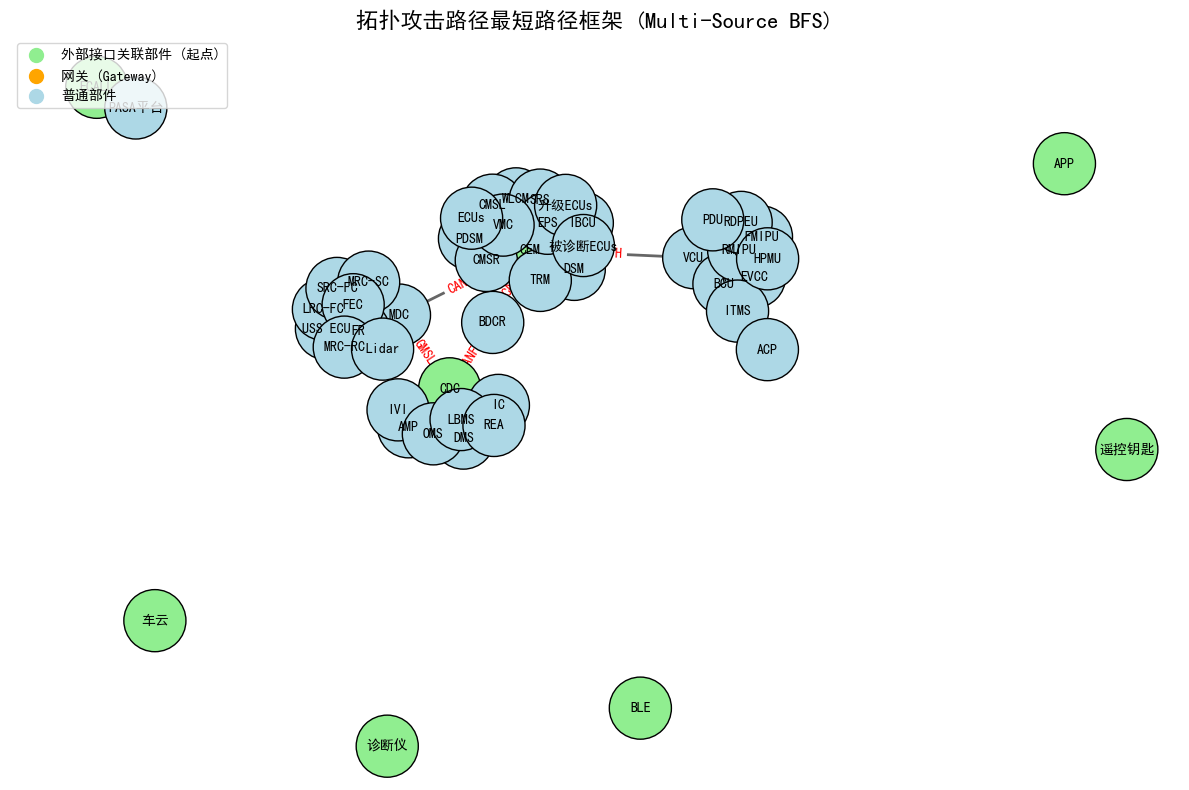

In [1]:
import json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, deque


# ==========================================
# 1. Data Models
# ==========================================
class TopologyElementType:
    COMPONENT = 1
    GATEWAY = 2
    EXTERNAL_COMPONENT = 3
    LINE = 4


class TopologyElement:
    def __init__(self, id, name="", type=None, color="",
                 source_id=None, target_id=None, is_gateway=False):
        self.id = id
        self.name = name
        self.type = type
        self.color = color
        self.source_id = source_id
        self.target_id = target_id
        self.is_gateway = is_gateway
        self.ids = []


class PathNode:
    def __init__(self, component_name_id, component_name,
                 pre_component_name_id, pre_component_name,
                 line_id, color, is_gateway):
        self.component_name_id = component_name_id
        self.component_name = component_name
        self.pre_component_name_id = pre_component_name_id
        self.pre_component_name = pre_component_name
        self.line_id = line_id
        self.color = color
        self.is_gateway = is_gateway


# ==========================================
# 2. Topology Parsing (unchanged)
# ==========================================
class TopologyMapUtil:
    @staticmethod
    def list_element_vo(cells):
        components = []
        for cell in cells:
            ele = TopologyElement(id=cell.get("id"))
            shape = cell.get("shape", "")
            attrs = cell.get("attrs", {})

            if shape == "custom-rounded-rect":
                stroke = attrs.get("body", {}).get("stroke", "")
                ele.type = (TopologyElementType.GATEWAY if stroke == "#016AFF"
                            else TopologyElementType.COMPONENT)
                ele.is_gateway = (stroke == "#016AFF")
                ele.color = stroke
                ele.name = attrs.get("text", {}).get("text", "")

            elif shape == "custom-rounded-rect-dash":
                ele.type = TopologyElementType.EXTERNAL_COMPONENT
                ele.color = attrs.get("body", {}).get("stroke", "")
                ele.name = attrs.get("text", {}).get("text", "")

            elif shape == "edge":
                ele.type = TopologyElementType.LINE
                ele.color = attrs.get("line", {}).get("stroke", "")
                ele.source_id = cell.get("source", {}).get("cell")
                ele.target_id = cell.get("target", {}).get("cell")

            components.append(ele)
        return components

    @staticmethod
    def get_distinct_components(element_vos):
        components = [
            e for e in element_vos
            if e.type in (TopologyElementType.COMPONENT,
                          TopologyElementType.GATEWAY,
                          TopologyElementType.EXTERNAL_COMPONENT)
            and e.name
        ]
        com_name_map = defaultdict(list)
        for c in components:
            com_name_map[c.name].append(c)

        distinct = []
        for name, elements in com_name_map.items():
            first = elements[0]
            first.ids = [e.id for e in elements]
            distinct.append(first)
        return distinct


# ==========================================
# 3. Multi-Source BFS Shortest Path Framework
# ==========================================
def compute_shortest_path_framework(external_interfaces, element_vos,
                                    protocol_legends, distinct_components):
    """
    Multi-source BFS (O(V+E)) computes shortest-path framework:

      target_id -> [
          {source_id, path (list[PathNode]), length, has_gateway},
          ...
      ]

    All paths to the same target are guaranteed to have the SAME length
    (the global shortest distance from ANY external-interface source).

    - Custom-rounded-rect-dash nodes (EXTERNAL_COMPONENT) with an external
      interface get a zero-length self-path: external_interface → itself.
    - Gateway filtering per-target is applied by the caller.
    """
    # ---- ID dedup mapping ----
    many_to_one_id_map = {}
    for comp in distinct_components:
        for old_id in comp.ids:
            many_to_one_id_map[old_id] = comp.id

    valid_colors = [p['color'] for p in protocol_legends]

    # ---- Filter valid lines & remap IDs ----
    lines = [e for e in element_vos
             if e.type == TopologyElementType.LINE and e.color in valid_colors]
    for line in lines:
        line.source_id = many_to_one_id_map.get(line.source_id, line.source_id)
        line.target_id = many_to_one_id_map.get(line.target_id, line.target_id)

    # ---- Build adjacency (undirected, edges tagged with color) ----
    com_dic = {c.id: c for c in distinct_components}
    adj = defaultdict(list)          # node_id -> [(neighbor_id, color)]
    for line in lines:
        if line.source_id in com_dic and line.target_id in com_dic:
            adj[line.source_id].append((line.target_id, line.color))
            adj[line.target_id].append((line.source_id, line.color))

    # ---- Identify external-interface component IDs ----
    ext_names = {ext['related_component'] for ext in external_interfaces}
    ext_com_ids = {c.id for c in distinct_components if c.name in ext_names}

    if not ext_com_ids:
        return {}, com_dic

    # =============================================================
    #  Multi-source BFS — single pass, O(V+E)
    # =============================================================
    INF = float('inf')
    dist = {cid: INF for cid in com_dic}
    pred = defaultdict(list)          # node_id -> [(predecessor_id, color)]

    queue = deque()
    for cid in ext_com_ids:
        if cid in com_dic:
            dist[cid] = 0
            queue.append(cid)

    while queue:
        cur = queue.popleft()
        cur_d = dist[cur]
        for nbr, color in adj.get(cur, []):
            if nbr not in com_dic:
                continue
            nd = cur_d + 1
            if nd < dist[nbr]:
                dist[nbr] = nd
                pred[nbr] = [(cur, color)]
                queue.append(nbr)
            elif nd == dist[nbr]:
                if (cur, color) not in pred[nbr]:
                    pred[nbr].append((cur, color))

    # =============================================================
    #  Reconstruct — return (source_id, path_list) pairs per target
    # =============================================================
    cache = {}    # target_id -> [(source_id, list[PathNode])]

    def reconstruct_with_source(tid):
        """All shortest-path (source_id, path) pairs reaching tid."""
        if tid in cache:
            return cache[tid]

        # Source node → self-path marker
        if tid in ext_com_ids:
            cache[tid] = [(tid, [])]
            return [(tid, [])]

        if tid not in pred or not pred[tid]:
            cache[tid] = []
            return []

        results = []
        for pid, color in pred[tid]:
            for src_id, sub in reconstruct_with_source(pid):
                node = PathNode(
                    component_name_id=tid,
                    component_name=com_dic[tid].name,
                    pre_component_name_id=pid,
                    pre_component_name=com_dic[pid].name,
                    line_id=color,
                    color=color,
                    is_gateway=com_dic[tid].is_gateway,
                )
                results.append((src_id, sub + [node]))

        cache[tid] = results
        return results

    # ---- Build per-target result dict ----
    target_paths = defaultdict(list)

    for tid in com_dic:
        if dist.get(tid, INF) == INF:
            continue
        for src_id, path in reconstruct_with_source(tid):
            target_paths[tid].append({
                'source_id': src_id,
                'path': path,
                'length': len(path),
                'has_gateway': any(n.is_gateway for n in path),
            })

    return dict(target_paths), com_dic


# ==========================================
# 4. Main Pipeline
# ==========================================
def process_and_visualize(json_path, excel_path):
    # ---- 1. Load data ----
    with open(json_path, 'r', encoding='utf-8') as f:
        topo_data = json.load(f)["data"]
    cells = topo_data.get("cells", [])
    protocol_legends = topo_data.get("lineData", [])
    color_name_map = {p['color']: p['name'] for p in protocol_legends}

    df = pd.read_excel(excel_path)
    external_interfaces = []
    for _, row in df.iterrows():
        external_interfaces.append({
            'external_interface': row['外部接口信息'],
            'related_component':  row['外部接口关联部件'],
        })

    # ---- 2. Parse topology ----
    element_vos = TopologyMapUtil.list_element_vo(cells)
    distinct_components = TopologyMapUtil.get_distinct_components(element_vos)

    # ---- 3. Shortest-path framework ----
    target_paths, com_dic = compute_shortest_path_framework(
        external_interfaces, element_vos, protocol_legends, distinct_components,
    )

    # ---- 4. Component → external-interface mapping ----
    comp_to_ext = defaultdict(list)
    for ext in external_interfaces:
        comp_to_ext[ext['related_component']].append(ext['external_interface'])

    # ================================================================
    # 5. Per-target filter & format
    # ================================================================
    final_path_strings = []
    final_path_objects = []

    for entries in target_paths.values():
        # Shortest-path filter: keep only minimum-length paths
        min_len = min(e['length'] for e in entries)
        candidates = [e for e in entries if e['length'] == min_len]

        # Gateway filter: if any shortest path goes through a gateway,
        # keep ONLY the ones that do
        any_gw = any(e['has_gateway'] for e in candidates)
        if any_gw:
            candidates = [e for e in candidates if e['has_gateway']]

        for entry in candidates:
            src_id = entry['source_id']
            path = entry['path']
            src_comp = com_dic[src_id]
            ext_ifs = comp_to_ext.get(src_comp.name, ["未知接口"])

            for ext_if in ext_ifs:
                if entry['length'] == 0:
                    # Self-path: [外部接口] -> 外部接口部件本身
                    desc = f"[{ext_if}] -> {src_comp.name}"
                else:
                    desc = f"[{ext_if}] -> {src_comp.name}"
                    for node in path:
                        proto = color_name_map.get(node.color, "未知协议")
                        desc += f" -> [{proto}] -> {node.component_name}"

                final_path_strings.append(desc)

            if path:
                final_path_objects.append(path)

    # ---- 6. Print ----
    unique = sorted(set(final_path_strings))
    print(f"共生成 {len(unique)} 条有效攻击路径（ BFS 最短路径框架）：")
    for idx, s in enumerate(unique):
        print(f"{idx + 1}. {s}")

    # ---- 7. Visualize ----
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False

    G = nx.Graph()
    ext_names = {ext['related_component'] for ext in external_interfaces}

    for comp in distinct_components:
        if comp.name in ext_names:
            c = 'lightgreen'
        elif comp.is_gateway:
            c = 'orange'
        else:
            c = 'lightblue'
        G.add_node(comp.name, color=c, type=comp.type)

    edge_labels = {}
    for path in final_path_objects:
        for node in path:
            u, v = node.pre_component_name, node.component_name
            proto = color_name_map.get(node.color, "未知")
            G.add_edge(u, v, color=node.color)
            edge_labels[(u, v)] = proto

    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, seed=42)
    node_colors = [G.nodes[n]['color'] for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=2000, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    nx.draw_networkx_edges(G, pos, width=2, alpha=0.6)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_color='red')

    plt.plot([], [], marker="o", ms=10, ls="", mec=None,
             color="lightgreen", label="外部接口关联部件 (起点)")
    plt.plot([], [], marker="o", ms=10, ls="", mec=None,
             color="orange", label="网关 (Gateway)")
    plt.plot([], [], marker="o", ms=10, ls="", mec=None,
             color="lightblue", label="普通部件")
    plt.legend(loc="upper left")
    plt.title("拓扑攻击路径最短路径框架 (Multi-Source BFS)", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    JSON_FILE_PATH = (
        r"D:\Jupyter profile\汽车信息安全风险评估\data\input\topology"
        r"\拓扑图数据导出2026_5_9 10_43_29.json"
    )
    EXCEL_FILE_PATH = (
        r"D:\Jupyter profile\汽车信息安全风险评估\data\input\information"
        r"\对外接口清单.xlsx"
    )

    try:
        process_and_visualize(JSON_FILE_PATH, EXCEL_FILE_PATH)
    except FileNotFoundError as e:
        print(f"文件未找到，请检查路径是否正确: {e}")
    except Exception as e:
        print(f"程序运行出错: {e}")
